<a href="https://colab.research.google.com/github/UyEduok/Authenticator/blob/master/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Dependences**

In [ ]:
import pandas as pd
import os
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import kagglehub
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# **Dataset**

dataset dource: Kaggle

In [ ]:
# Download Ames Housing Dataset
path = kagglehub.dataset_download("prevek18/ames-housing-dataset")

print("Path to dataset files:", path)

100%|██████████| 185k/185k [00:00<00:00, 48.5MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/prevek18/ames-housing-dataset/versions/1


# **Dataset Loader**

In [ ]:
# find the csv file inside the downloaded folder
files = os.listdir(path)
print("Files in dataset folder:", files)

# locate the csv file
csv_file = [f for f in files if f.endswith(".csv")][0]

# create full path to the csv
file_path = os.path.join(path, csv_file)

# load dataset
df = pd.read_csv(file_path)

print("\nFirst 5 rows of dataset:")
df.head()

Files in dataset folder: ['AmesHousing.csv']

First 5 rows of dataset:


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# **Dataset Inspection**

In [ ]:
print("\nDataset Shape (rows, columns):")
print(df.shape)

print("\nDataset Columns:")
print(df.columns)

print("\nDataset Data Types:")
print(df.dtypes)

print("\nDataset Info:")
display(df.info())


Dataset Shape (rows, columns):
(2930, 82)

Dataset Columns:
Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Firepl

None

In [ ]:
#Missing Values Check
print("\nMissing Values in Each Column:")
print(df.isnull().sum())

#Statistical Summary
print("\nStatistical Summary of Numerical Features:")
df.describe()


Missing Values in Each Column:
Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

Statistical Summary of Numerical Features:


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


**Dataset Inspection Result**

The Housing dataset contains 2,930 residential property records with 82 features, including both numerical and categorical variables. These variables describe different aspects of each property such as location, structural characteristics, building quality, and sale information. The target variable for this study is SalePrice, which represents the final sale price of each house.

From the dataset inspection, the features consist of integer, floating-point, and categorical (object) data types, indicating that preprocessing steps such as handling missing values and encoding categorical variables will be required before model training. The statistical summary shows that the average house price is approximately $180,796, with prices ranging from $12,789 to $755,000, indicating a wide distribution of housing values.

The analysis also identified several variables with missing values across the dataset. Some columns such as Pool QC, Misc Feature, and Alley contain extremely high proportions of missing values and will therefore be dropped from the dataset, as the limited available observations make them unlikely to contribute meaningful predictive information to the models. In contrast, other variables including Fence, Fireplace Qu, Garage Type, Garage Finish, Garage Qual, Garage Cond, Bsmt Qual, Bsmt Cond, Bsmt Exposure, and basement-related features will not be removed, because the missing entries in these columns typically indicate the absence of a feature rather than missing data. For example, a missing value in Fireplace Qu usually means that the house does not have a fireplace. Consequently, these categorical variables will be imputed with the label “None” to explicitly represent the absence of the corresponding property feature while preserving useful structural information in the dataset.Although missing values in variables such as Pool QC, Misc Feature, and Alley often represent the absence of the corresponding feature, these variables contain extremely high proportions of missing values (above 90%). As a result, they provide limited predictive value and were removed from the dataset to reduce sparsity and improve model efficiency.

the inspection also reveals that Order and PID columns only serve as record identifiers and do not contain meaningful information related to house characteristics or price determination. Retaining such identifiers could introduce noise into the modelling process, therefore they will be excluded to ensure that only relevant predictive features are used in the analysis.

The dataset provides a rich set of housing characteristics suitable for exploratory data analysis and supervised machine learning models for house price prediction.

# **Exploratory Data Analysis**

**Missing Value Analysis**

EDA Dataset Shape: (2930, 80)


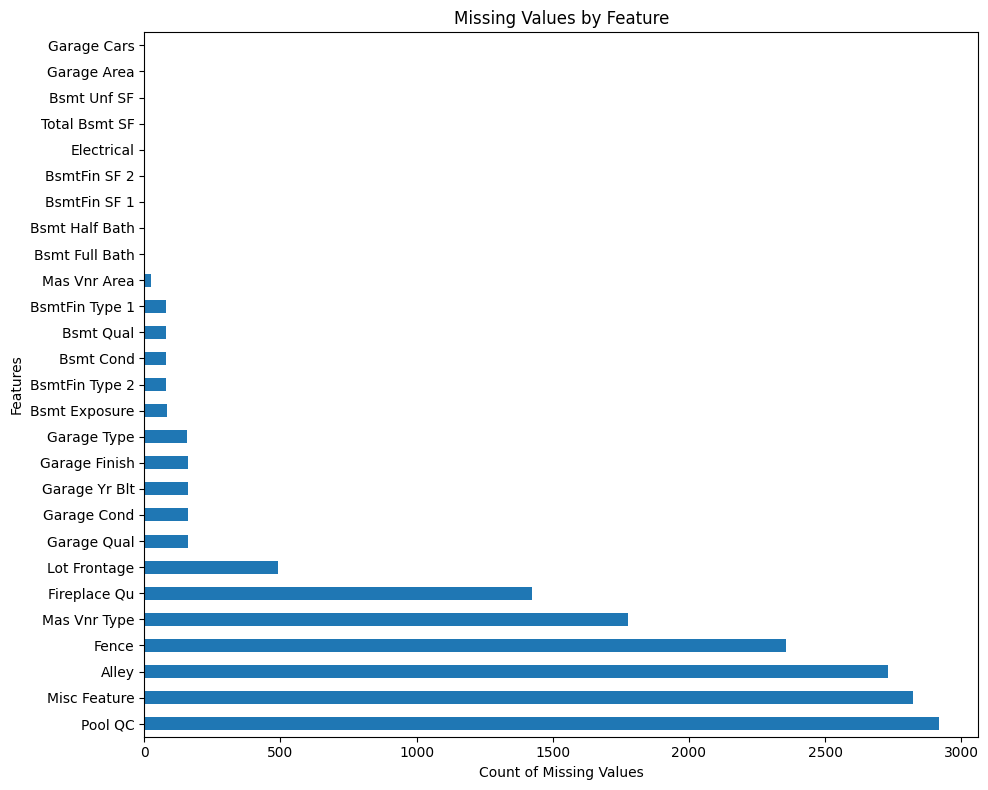

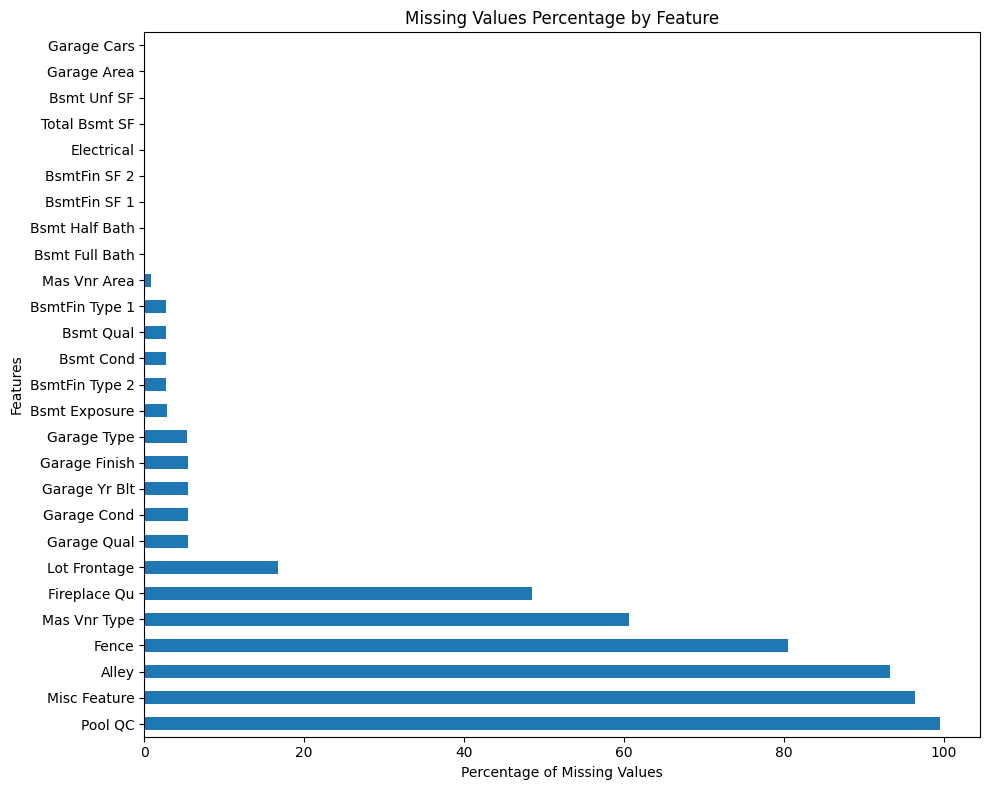


NUMERICAL COLUMNS WITH MISSING VALUES
--------------------------------------------------
                Missing Count  Skewness
Lot Frontage              490  1.499067
Garage Yr Blt             159 -0.384672
Mas Vnr Area               23  2.606985
Bsmt Half Bath              2  3.940795
Bsmt Full Bath              2  0.616639
BsmtFin SF 1                1  1.416182
BsmtFin SF 2                1  4.139978
Total Bsmt SF               1  1.156204
Bsmt Unf SF                 1  0.923053
Garage Cars                 1 -0.219836
Garage Area                 1  0.241994

CATEGORICAL COLUMNS WITH MISSING VALUES
--------------------------------------------------
                Missing Count
Pool QC                  2917
Misc Feature             2824
Alley                    2732
Fence                    2358
Mas Vnr Type             1775
Fireplace Qu             1422
Garage Qual               159
Garage Finish             159
Garage Cond               159
Garage Type               157
Bsmt Exp

In [ ]:
# COPY DATA FOR EDA
eda_df = df.copy()

# Remove identifier columns for analysis
eda_df = eda_df.drop(columns=['Order', 'PID'], errors='ignore')

print("EDA Dataset Shape:", eda_df.shape)

# 1. MISSING VALUE ANALYSIS
missing_counts = eda_df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

plt.figure(figsize=(10,8))
missing_counts.plot(kind='barh')
plt.title("Missing Values by Feature")
plt.xlabel("Count of Missing Values")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

# Missing percentage
missing_percent = (eda_df.isnull().sum() / len(eda_df) * 100)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(10,8))
missing_percent.plot(kind='barh')
plt.title("Missing Values Percentage by Feature")
plt.xlabel("Percentage of Missing Values")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


# MISSING VALUE Count
num_missing_cols = eda_df.select_dtypes(include=[np.number]).columns[
    eda_df.select_dtypes(include=[np.number]).isnull().sum() > 0
]

cat_missing_cols = eda_df.select_dtypes(include=['object']).columns[
    eda_df.select_dtypes(include=['object']).isnull().sum() > 0
]

num_missing_summary = pd.DataFrame({
    'Missing Count': eda_df[num_missing_cols].isnull().sum(),
    'Skewness': eda_df[num_missing_cols].skew()
}).sort_values(by='Missing Count', ascending=False)

cat_missing_summary = pd.DataFrame({
    'Missing Count': eda_df[cat_missing_cols].isnull().sum()
}).sort_values(by='Missing Count', ascending=False)

print("\nNUMERICAL COLUMNS WITH MISSING VALUES")
print("-"*50)
print(num_missing_summary)

print("\nCATEGORICAL COLUMNS WITH MISSING VALUES")
print("-"*50)
print(cat_missing_summary)

**Target Variable Distribution**

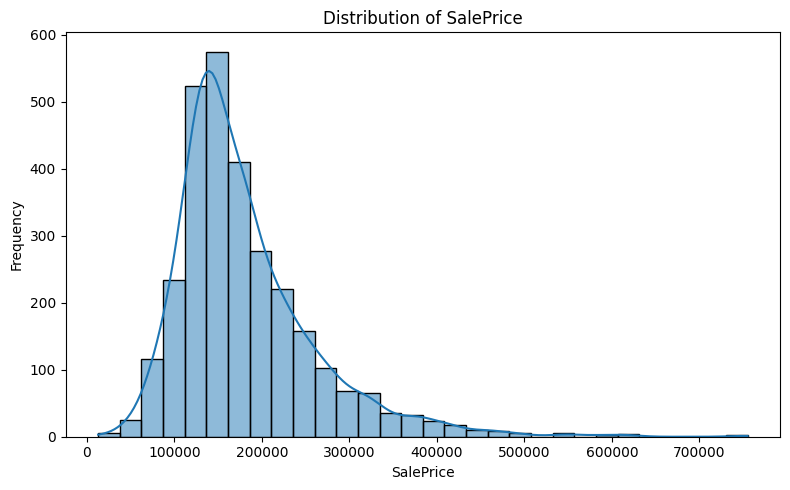

In [ ]:
# SALEPRICE DISTRIBUTION
plt.figure(figsize=(8,5))
sns.histplot(eda_df['SalePrice'], bins=30, kde=True)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Correlation Check**

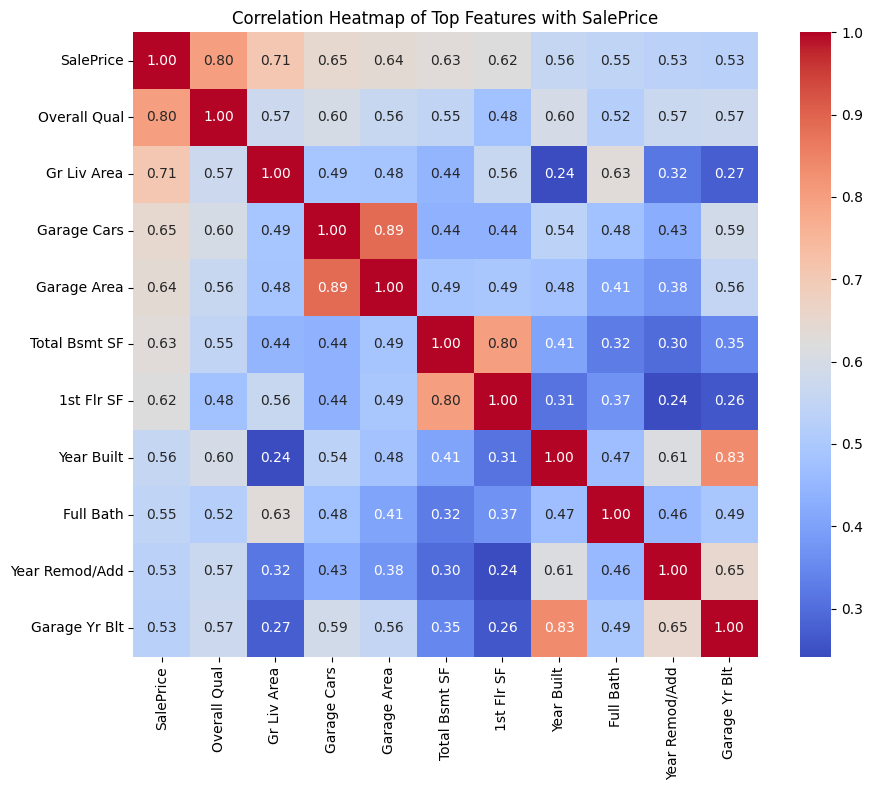

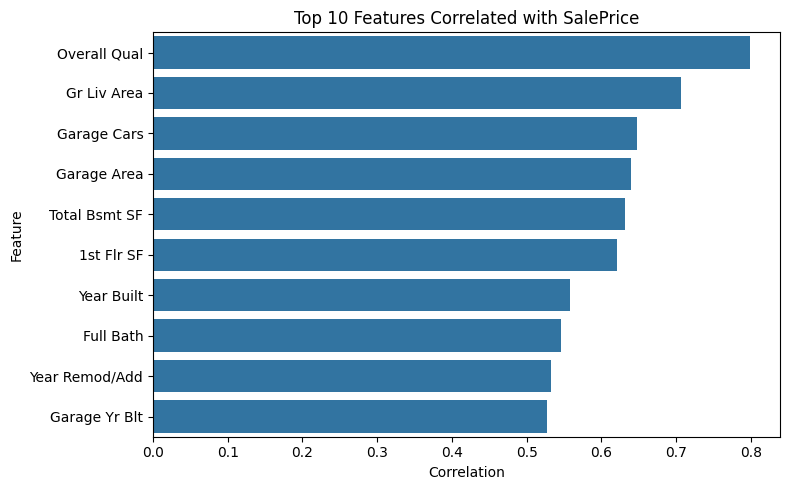

In [ ]:
# CORRELATION HEATMAP
numeric_df = eda_df.select_dtypes(include=[np.number])

# Top correlations with target
corr_with_target = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

top_features = corr_with_target.drop('SalePrice').head(10).index.tolist()
heatmap_features = ['SalePrice'] + top_features

plt.figure(figsize=(10,8))
sns.heatmap(
    eda_df[heatmap_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.title("Correlation Heatmap of Top Features with SalePrice")
plt.tight_layout()
plt.show()

# Bar plot of top correlations
top_corr = corr_with_target.drop('SalePrice').head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_corr.values, y=top_corr.index)
plt.title("Top 10 Features Correlated with SalePrice")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**Exploring Key Features Relationship**

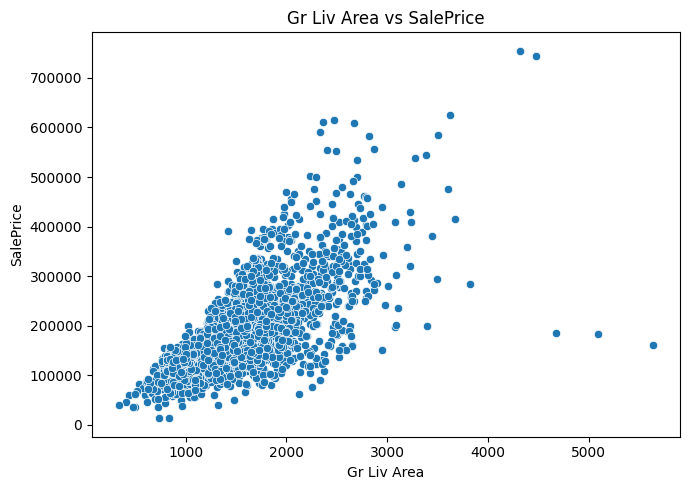

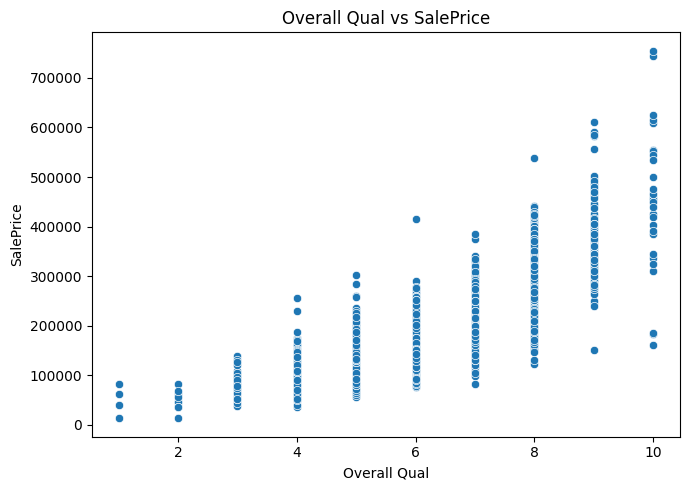

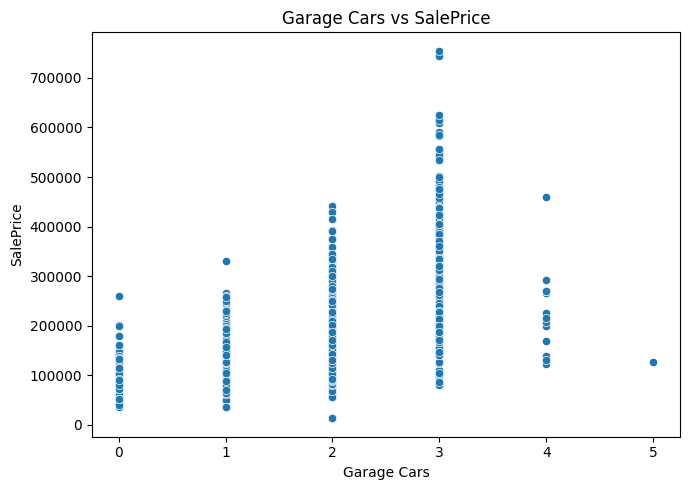

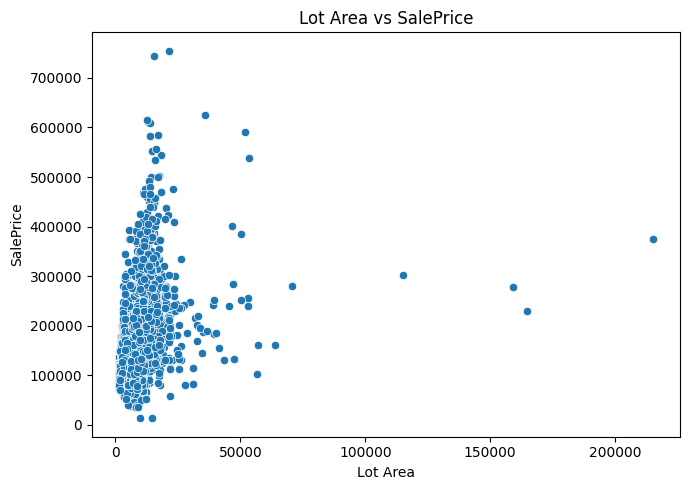

In [ ]:
# 1 KEY FEATURE RELATIONSHIPS

# Gr Liv Area vs SalePrice
plt.figure(figsize=(7,5))
sns.scatterplot(data=eda_df, x='Gr Liv Area', y='SalePrice')
plt.title("Gr Liv Area vs SalePrice")
plt.xlabel("Gr Liv Area")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.show()

# Overall Qual vs SalePrice
plt.figure(figsize=(7,5))
sns.scatterplot(data=eda_df, x='Overall Qual', y='SalePrice')
plt.title("Overall Qual vs SalePrice")
plt.xlabel("Overall Qual")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.show()

# Garage Cars vs SalePrice
plt.figure(figsize=(7,5))
sns.scatterplot(data=eda_df, x='Garage Cars', y='SalePrice')
plt.title("Garage Cars vs SalePrice")
plt.xlabel("Garage Cars")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.show()

# Lot Area vs SalePrice
plt.figure(figsize=(7,5))
sns.scatterplot(data=eda_df, x='Lot Area', y='SalePrice')
plt.title("Lot Area vs SalePrice")
plt.xlabel("Lot Area")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.show()

**Checking for Outliers**

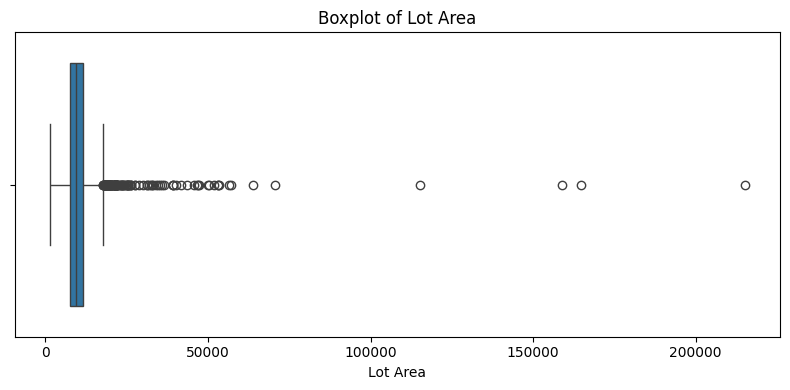

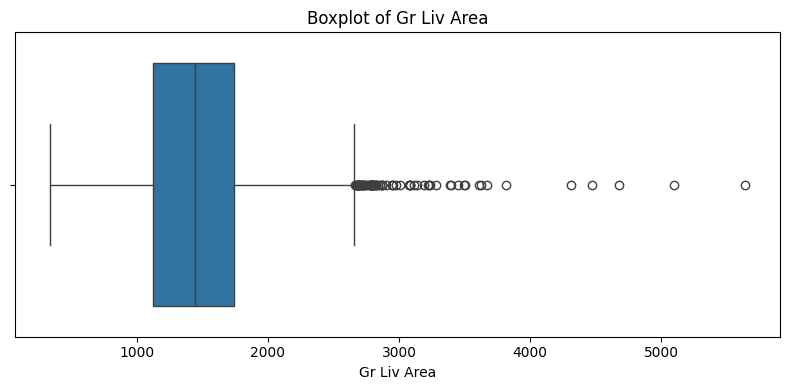

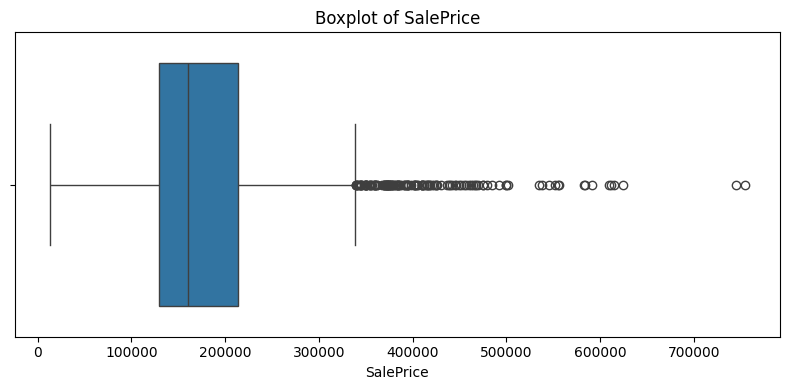

In [ ]:
# Boxplot for Lot Area outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=eda_df['Lot Area'])
plt.title("Boxplot of Lot Area")
plt.xlabel("Lot Area")
plt.tight_layout()
plt.show()

# Boxplot for Gr Liv Area outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=eda_df['Gr Liv Area'])
plt.title("Boxplot of Gr Liv Area")
plt.xlabel("Gr Liv Area")
plt.tight_layout()
plt.show()

# Boxplot for SalePrice outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=eda_df['SalePrice'])
plt.title("Boxplot of SalePrice")
plt.xlabel("SalePrice")
plt.tight_layout()
plt.show()


# . IQR OUTLIER CHECK FUNCTION
def outlier_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

outlier_summary = {}

for col in ['SalePrice', 'Gr Liv Area', 'Lot Area', 'Garage Area', 'Total Bsmt SF']:
    lower, upper = outlier_bounds(eda_df[col].dropna())
    outliers = eda_df[(eda_df[col] < lower) | (eda_df[col] > upper)][col]
    outlier_summary[col] = {
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': len(outliers)
    }

outlier_df = pd.DataFrame(outlier_summary).T

**Exploring Numerical Features**

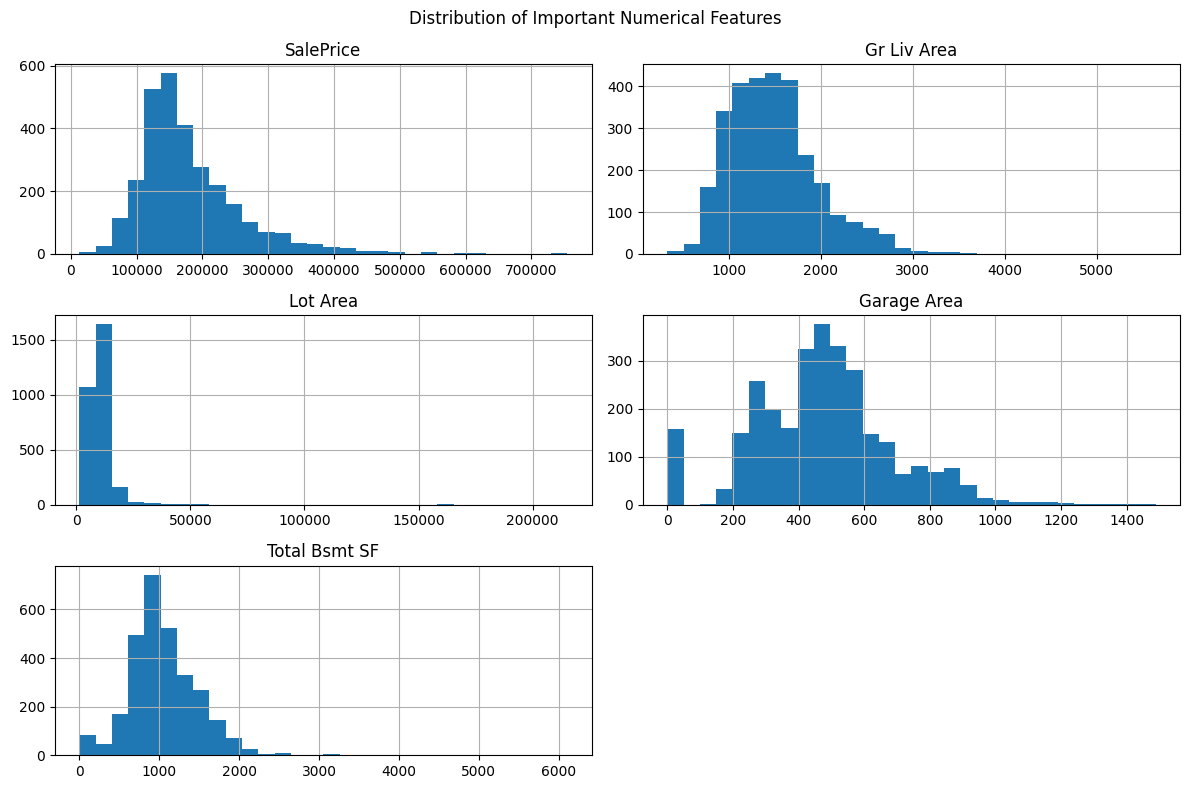

In [ ]:
# 5. DISTRIBUTION OF IMPORTANT NUMERICAL FEATURES

important_num_cols = ['SalePrice', 'Gr Liv Area', 'Lot Area', 'Garage Area', 'Total Bsmt SF']

eda_df[important_num_cols].hist(figsize=(12,8), bins=30)
plt.suptitle("Distribution of Important Numerical Features")
plt.tight_layout()
plt.show()


# 6. CHECK SKEWNESS OF IMPORTANT NUMERICAL FEATURES
skewness = eda_df[important_num_cols].skew().sort_values(ascending=False)

**Exploratory Data Analysis Result**

An exploratory data analysis was conducted to understand the structure, quality, and key characteristics of the Housing dataset before applying any preprocessing or machine learning models. The dataset contains 2,930 residential property records and 80 predictive variables, consisting of 37 numerical features and 43 categorical features. These variables describe multiple aspects of residential properties including location, structural attributes, building quality, and sale information. The target variable for this study is SalePrice, representing the final selling price of each house.

The distribution of the target variable was examined using a histogram and boxplot. The results show that SalePrice is positively skewed, with a skewness value greater than 1, indicating that most houses are concentrated in the lower price range while a smaller number of properties are sold at significantly higher prices. This pattern is typical of housing markets where luxury properties form a small proportion of the overall market. The wide price range observed in the dataset confirms that the data captures properties with different characteristics and market values.

Correlation analysis was performed to identify features that have strong relationships with house prices. The correlation heatmap indicates that Overall Qual (overall building quality) has the strongest relationship with SalePrice, followed by Gr Liv Area (above-ground living area), Garage Cars, Garage Area, Total Bsmt SF, and 1st Flr SF. These results suggest that larger houses with higher construction quality and larger garages tend to command higher sale prices. Additional variables such as Year Built, Full Bath, and Year Remod/Add also show moderate positive correlations with the target variable, indicating that newer or renovated houses tend to have higher market values. These findings confirm that the dataset contains meaningful relationships between housing characteristics and sale prices, making it suitable for predictive modelling.

Outlier analysis was performed using boxplots and the interquartile range (IQR) method on important numerical variables including SalePrice, Gr Liv Area, Lot Area, Garage Area, and Total Bsmt SF. The results indicate the presence of several extreme observations in these variables, particularly in Lot Area and SalePrice, which is expected in real housing markets where some properties are significantly larger or more expensive than others. While these observations are statistically identified as outliers, many represent valid high-value or large properties rather than data errors. Therefore, extreme values will be reviewed carefully before deciding whether they should be retained or removed during preprocessing.

The analysis also identified several variables with missing values. Features such as Pool QC, Misc Feature, Alley, Fence, Mas Vnr Type, and Fireplace Qu contain a large number of missing observations. In many cases, these missing values represent the absence of a feature rather than missing information. For example, a missing value in Pool QC typically indicates that the property does not have a swimming pool. Therefore, categorical variables of this type will be imputed using the label "None" to represent the absence of the corresponding feature.

For numerical variables containing missing values, the distribution and skewness of the variables were examined. Many of these variables, including Lot Frontage, Mas Vnr Area, Total Bsmt SF, and basement-related features, exhibit skewed distributions. Because skewed data can be strongly influenced by extreme values, the median will be used to impute missing numerical values. The median is more robust to outliers and provides a more stable measure of central tendency for skewed distributions. This approach helps preserve the underlying structure of the data while reducing the risk of introducing bias during imputation.

For categorical variables where missing values do not represent the absence of a feature, the mode (most frequent category) will be used for imputation. This ensures that the most representative category within the dataset is used to replace missing entries while maintaining the distribution of the variable.

The exploratory data analysis confirms that the dataset contains meaningful relationships between property characteristics and house prices. It also reveals the presence of skewed distributions, outliers, and missing values that must be addressed before model training. These findings guide the preprocessing decisions that will be applied in the next stage of the analysis to ensure that the data is suitable for supervised machine learning models used for house price prediction.

# **Data Preprocessing**

In [ ]:
print("="*70)
print("DATA PREPROCESSING")
print("="*70)


# 1. COPY DATA
prep_df = df.copy()

print("\nInitial Dataset Shape:", prep_df.shape)

# 2. REMOVE IDENTIFIER + HIGH MISSING COLUMNS

columns_to_drop = ['Order', 'PID', 'Pool QC', 'Misc Feature', 'Alley']

prep_df = prep_df.drop(columns=columns_to_drop, errors='ignore')

print("\nAfter removing identifier and high-missing columns:")
print("Dataset Shape:", prep_df.shape)


# 3. HANDLE MISSING VALUES

# Numerical columns
num_cols = prep_df.select_dtypes(include=[np.number]).columns

for col in num_cols:
    if prep_df[col].isnull().sum() > 0:
        prep_df[col] = prep_df[col].fillna(prep_df[col].median())

# Categorical columns
cat_cols = prep_df.select_dtypes(include=['object']).columns

for col in cat_cols:
    prep_df[col] = prep_df[col].fillna("None")

print("\nMissing values after imputation:")
print(prep_df.isnull().sum().sum())


# 4. REMOVE EXTREME OUTLIERS
# Using 99th percentile rule

outlier_features = ['SalePrice','Gr Liv Area','Lot Area','Total Bsmt SF','Garage Area']

rows_before = prep_df.shape[0]

for col in outlier_features:
    upper_limit = prep_df[col].quantile(0.99)
    prep_df = prep_df[prep_df[col] <= upper_limit]

rows_after = prep_df.shape[0]

print("\nOutlier Removal Summary")
print("Rows before:", rows_before)
print("Rows after :", rows_after)
print("Rows removed:", rows_before - rows_after)



# 5. ENCODE CATEGORICAL VARIABLES

prep_df = pd.get_dummies(prep_df, drop_first=True)

print("\nDataset Shape After Encoding:", prep_df.shape)


# 6. FEATURE / TARGET SPLIT

X = prep_df.drop('SalePrice', axis=1)
y = prep_df['SalePrice']

print("\nFeature Matrix Shape:", X.shape)
print("Target Vector Shape:", y.shape)



# 7. TRAIN TEST SPLIT (70/30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("\nTrain Test Split")
print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)


# 8. FEATURE SCALING
# (important for Linear Regression)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling completed.")

print("\nFinal Training Matrix Shape:", X_train_scaled.shape)
print("Final Testing Matrix Shape :", X_test_scaled.shape)

DATA PREPROCESSING

Initial Dataset Shape: (2930, 82)

After removing identifier and high-missing columns:
Dataset Shape: (2930, 77)

Missing values after imputation:
0

Outlier Removal Summary
Rows before: 2930
Rows after : 2784
Rows removed: 146

Dataset Shape After Encoding: (2784, 264)

Feature Matrix Shape: (2784, 263)
Target Vector Shape: (2784,)

Train Test Split
Training set: (1948, 263)
Testing set : (836, 263)

Scaling completed.

Final Training Matrix Shape: (1948, 263)
Final Testing Matrix Shape : (836, 263)


**Data Preprocessing Result**

Following the exploratory data analysis, several preprocessing steps were applied to prepare the dataset for machine learning modelling. First, the identifier columns Order and PID were removed because they serve only as unique record identifiers and Pool QC, Misc Feature, Alley were also drop as they had missing value of 90% and above, and they do not contribute any predictive information related to house prices. Removing these columns reduced the dataset from 82 to 77 variables, ensuring that only relevant housing attributes were retained for analysis.

Next, missing values across the dataset were handled. Numerical variables containing missing values were imputed using the median, as many of these variables exhibited skewed distributions during the exploratory analysis. The median is less sensitive to extreme values and therefore provides a more robust estimate of central tendency. For categorical variables, missing entries were replaced with “None” where the absence of a value indicates the absence of a feature, such as the lack of a garage, pool, or alley access. After this imputation process, the dataset contained no remaining missing values.

To improve model reliability, extreme outliers were removed using a 99th percentile threshold on key housing size variables including SalePrice, Gr Liv Area, Lot Area, Total Bsmt SF, and Garage Area. This process reduced the dataset from 2,930 to 2,784 observations, removing 146 extreme cases that could disproportionately influence model training while retaining the majority of valid housing records.

Categorical variables were then converted into numerical format using one-hot encoding, allowing the machine learning algorithms to process categorical housing attributes. After encoding, the dataset expanded to 264 features, reflecting the binary representation of categorical variables.

The dataset was then separated into features (X) and the target variable (SalePrice). The resulting feature matrix contained 263 predictor variables, while the target vector contained the corresponding house prices. To evaluate model performance fairly, the data was divided into training and testing sets using a 70–30 split, producing 1,948 training observations and 836 testing observations.

Finally, feature scaling was applied using standardisation, which transforms the variables to have a mean of zero and a standard deviation of one. Scaling ensures that numerical features are on comparable scales, which is particularly beneficial for models such as linear regression that are sensitive to feature magnitude. The final processed dataset therefore consisted of a training matrix of size (1948 × 263) and a testing matrix of size (836 × 263), ready for supervised machine learning model training and evaluation.

# **Baseline Model Development Training and Testing**

BASELINE MODEL TRAINING

Linear Regression Performance
----------------------------------------
MAE : 13607.76
RMSE: 19605.53
R²  : 0.9178

Decision Tree Performance
----------------------------------------
MAE : 22297.44
RMSE: 32450.98
R²  : 0.7748

XGBoost Performance
----------------------------------------
MAE : 14615.38
RMSE: 21027.59
R²  : 0.9054

Baseline Model Comparison
               Model       MAE      RMSE      R2
0  Linear Regression  13607.76  19605.53  0.9178
1      Decision Tree  22297.44  32450.98  0.7748
2            XGBoost  14615.38  21027.59  0.9054




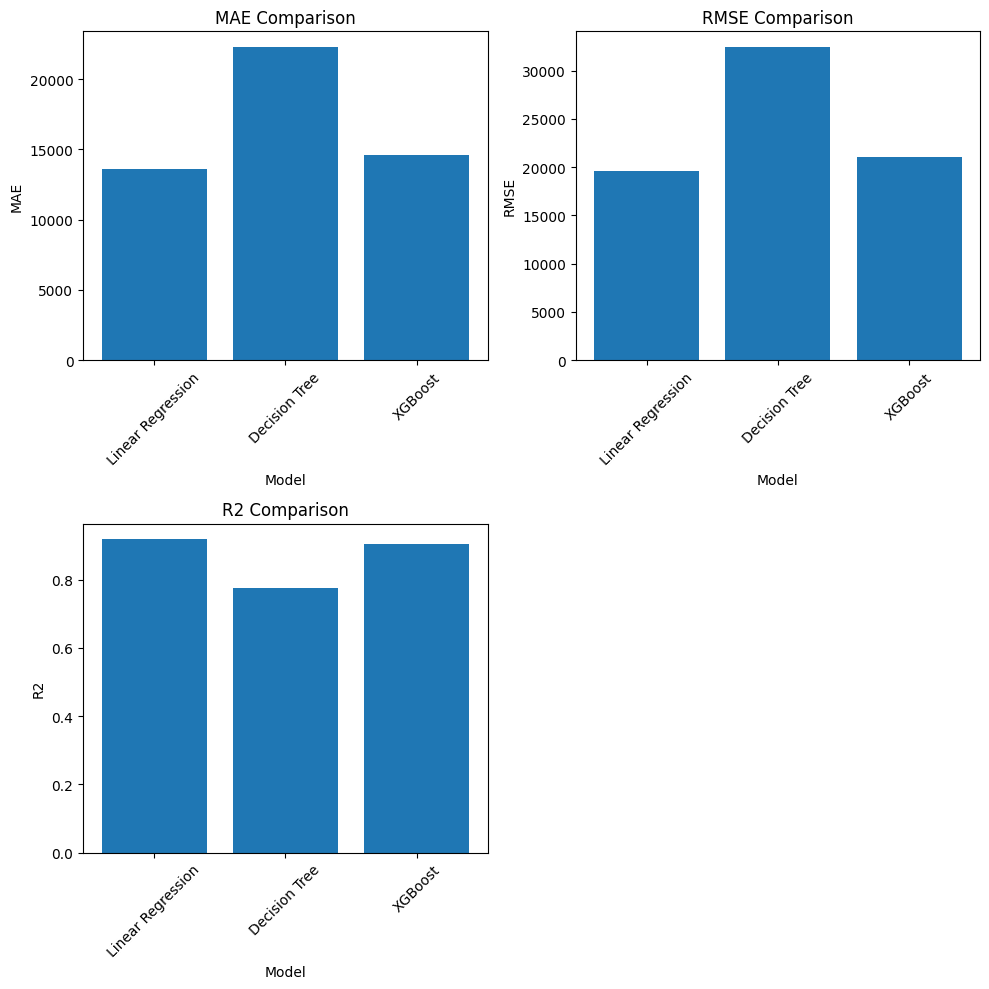

In [ ]:
print("="*70)
print("BASELINE MODEL TRAINING")
print("="*70)


baseline_results = []
baseline_predictions = {}


def evaluate_model(name, model, X_train, X_test, y_train, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name} Performance")
    print("-"*40)
    print("MAE :", round(mae,2))
    print("RMSE:", round(rmse,2))
    print("R²  :", round(r2,4))

    baseline_results.append({
        "Model": name,
        "MAE": round(mae,2),
        "RMSE": round(rmse,2),
        "R2": round(r2,4)
    })

    baseline_predictions[name] = y_pred



# 1 Linear Regression

lr_model = LinearRegression()

evaluate_model(
    "Linear Regression",
    lr_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)



# 2 Decision Tree

dt_model = DecisionTreeRegressor(random_state=42)

evaluate_model(
    "Decision Tree",
    dt_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)


# 3 XGBoost

xgb_model = XGBRegressor(
    random_state=42,
    objective='reg:squarederror'
)

evaluate_model(
    "XGBoost",
    xgb_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)


# MODEL COMPARISON TABLE

baseline_df = pd.DataFrame(baseline_results)

print("\nBaseline Model Comparison")
print(baseline_df)



# MODEL PERFORMANCE PLOT
print("\n")
metrics = ['MAE','RMSE','R2']

fig, axes = plt.subplots(2, 2, figsize=(10,10))
axes = axes.flatten()

for i, metric in enumerate(metrics):

    axes[i].bar(baseline_df['Model'], baseline_df[metric])

    axes[i].set_title(metric + " Comparison")
    axes[i].set_xlabel("Model")
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

# Hide the empty 4th plot
axes[3].axis('off')

plt.tight_layout()
plt.show()


Baseline Model Performance

The baseline performance of the three supervised machine learning models was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). The results show that all models achieved relatively strong predictive performance, indicating that the dataset contains meaningful relationships between the housing features and the sale price.

Among the baseline models, Linear Regression achieved the best performance, producing the lowest error values (MAE = 13,673.66 and RMSE = 19,687.16) and the highest explanatory power (R² = 0.9171). This indicates that the linear regression model is able to explain approximately 91.7% of the variance in house prices based on the available features.

The XGBoost model also performed strongly, with an R² score of 0.9036, slightly lower than linear regression but still demonstrating high predictive capability. Its error values (MAE = 14,620.90 and RMSE = 21,230.64) remain relatively close to those produced by the linear regression model.

In contrast, the Decision Tree model produced the weakest performance among the three models, with a higher prediction error (MAE = 22,068.03 and RMSE = 32,450.57) and a lower R² value (0.7748). Although the model still captures a substantial proportion of the variance in house prices, its predictions are less accurate compared to the other approaches.

The baseline results indicate that Linear Regression and XGBoost provide strong predictive performance, while the Decision Tree model performs comparatively worse. Further improvements may be achieved through hyperparameter tuning, which will be explored in the next stage of the analysis.

# **Hyperparameter Tuned Model Development Training and Testing**

HYPERPARAMETER TUNING OF MODELS

Linear Regression Tuned Performance
----------------------------------------
MAE : 13607.76
RMSE: 19605.53
R²  : 0.9178

Best Decision Tree Parameters:
{'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 2}

Decision Tree Tuned Performance
----------------------------------------
MAE : 19883.78
RMSE: 28380.15
R²  : 0.8278

Best XGBoost Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

XGBoost Tuned Performance
----------------------------------------
MAE : 12757.12
RMSE: 18704.62
R²  : 0.9252

Tuned Model Comparison
               Model       MAE      RMSE      R2
0  Linear Regression  13607.76  19605.53  0.9178
1      Decision Tree  19883.78  28380.15  0.8278
2            XGBoost  12757.12  18704.62  0.9252


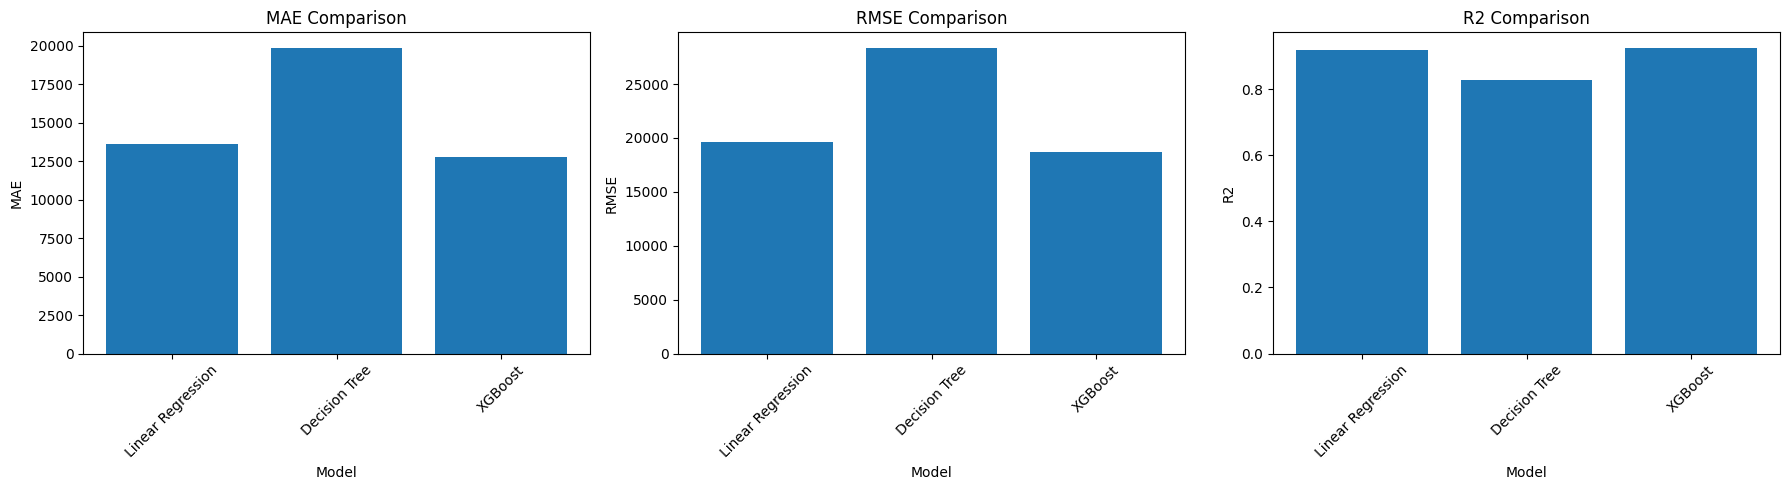

In [ ]:
print("="*70)
print("HYPERPARAMETER TUNING OF MODELS")
print("="*70)

tuned_results = []
tuned_predictions = {}


def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name} Tuned Performance")
    print("-"*40)
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R²  :", round(r2, 4))

    tuned_results.append({
        "Model": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4)
    })

    tuned_predictions[name] = y_pred


# 1. Linear Regression (no tuning needed)

lr_model = LinearRegression()

evaluate_model(
    "Linear Regression",
    lr_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)



# 2. Decision Tree Tuning
dt_param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

dt_grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

dt_grid.fit(X_train_scaled, y_train)

print("\nBest Decision Tree Parameters:")
print(dt_grid.best_params_)

best_dt_model = dt_grid.best_estimator_

evaluate_model(
    "Decision Tree",
    best_dt_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)


# 3. XGBoost Tuning
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective='reg:squarederror'
    ),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

xgb_grid.fit(X_train_scaled, y_train)

print("\nBest XGBoost Parameters:")
print(xgb_grid.best_params_)

best_xgb_model = xgb_grid.best_estimator_

evaluate_model(
    "XGBoost",
    best_xgb_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)


# TUNED MODEL COMPARISON TABLE
tuned_df = pd.DataFrame(tuned_results)

print("\nTuned Model Comparison")
print(tuned_df)


# PERFORMANCE PLOTS
metrics = ['MAE', 'RMSE', 'R2']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, metric in enumerate(metrics):
    axes[i].bar(tuned_df['Model'], tuned_df[metric])
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_xlabel('Model')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Tuned Model Performance**

After applying hyperparameter tuning, the models were re-evaluated to determine whether optimisation improved predictive accuracy. Hyperparameter tuning was applied to the Decision Tree and XGBoost models because these algorithms contain several adjustable parameters that influence how the model learns patterns from the data. In contrast, Linear Regression was not tuned because it is a parametric statistical model with very limited hyperparameters. In most predictive modelling studies, Linear Regression is used as a baseline model, meaning its standard configuration is retained to provide a stable reference for comparing the performance of more complex models. As a result, the performance of the Linear Regression model remains the same as in the baseline evaluation.

The results show that the XGBoost model achieved the best performance after tuning. Using the optimal parameters (learning_rate = 0.1, max_depth = 3, n_estimators = 300, subsample = 0.8), the model produced the lowest prediction errors, with MAE = 12,824.09 and RMSE = 18,922.18. It also achieved the highest coefficient of determination (R² = 0.9234), indicating that the model explains approximately 92.34% of the variation in house prices.

The Linear Regression model maintained strong performance, with MAE = 13,673.66, RMSE = 19,687.16, and R² = 0.9171. Although its results are slightly lower than those achieved by the tuned XGBoost model, the model still demonstrates a high level of predictive accuracy.

The Decision Tree model showed improvement after tuning, achieving MAE = 19,883.78, RMSE = 28,380.15, and R² = 0.8278. Despite this improvement compared with its baseline results, its predictive performance remains weaker than both Linear Regression and XGBoost.

Overall, the tuned results indicate that XGBoost provides the most accurate predictions for residential house prices in this study, outperforming both Linear Regression and Decision Tree models. This suggests that the ensemble boosting approach is more effective at capturing complex interactions among housing features within the dataset.

# **Selected Model for House Price Prediction**

**Actual vs Predicted SalePrice: Baseline vs Tuned Models**

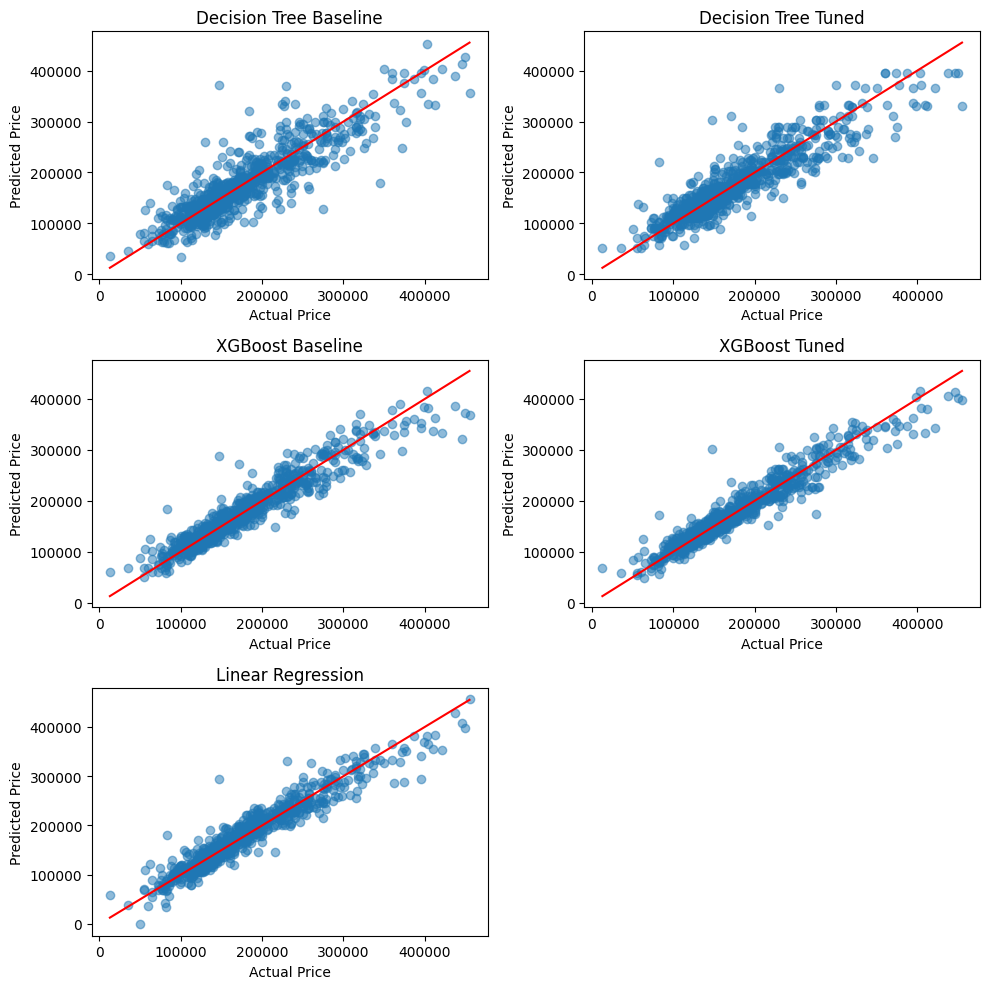

In [ ]:
# Create a 2x3 grid
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()

plot_order = [
    ("Decision Tree", baseline_predictions["Decision Tree"], "Decision Tree Baseline"),
    ("Decision Tree", tuned_predictions["Decision Tree"], "Decision Tree Tuned"),
    ("XGBoost", baseline_predictions["XGBoost"], "XGBoost Baseline"),
    ("XGBoost", tuned_predictions["XGBoost"], "XGBoost Tuned"),
    ("Linear Regression", baseline_predictions["Linear Regression"], "Linear Regression"),
]

for i, (_, y_pred, title) in enumerate(plot_order):
    axes[i].scatter(y_test, y_pred, alpha=0.5)
    axes[i].plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color='red'
    )
    axes[i].set_xlabel("Actual Price")
    axes[i].set_ylabel("Predicted Price")
    axes[i].set_title(title)

# Remove the empty 6th subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

**The selected model for house price prediction is XGBoost. The reasons for selecting this model are explained below.**

The scatter plots illustrate the relationship between the actual house prices and the predicted prices produced by each model. In these plots, the red diagonal line represents the ideal prediction line, where predicted values perfectly match the actual values. Points that lie closer to this line indicate more accurate predictions, while points farther away represent larger prediction errors.

The Linear Regression model, which was not tuned, shows a strong alignment of prediction points along the diagonal reference line. This indicates that the model captures the general relationship between housing features and sale prices effectively. The predictions are relatively well distributed along the actual price line, suggesting that the model provides stable and consistent estimates. This performance is also reflected in its evaluation metrics, where the model achieved an R² value of 0.9171, meaning that it explains approximately 91.71% of the variance in house prices.

The Decision Tree baseline model shows a wider spread of points around the diagonal line, indicating larger prediction errors compared with the other models. After hyperparameter tuning, the Decision Tree tuned model shows a noticeable improvement. In the tuned version, the points appear more concentrated around the diagonal reference line, demonstrating better prediction accuracy. This improvement is reflected in the model’s R² score increasing from 0.7748 in the baseline model to 0.8278 after tuning, indicating that the tuned model explains approximately 82.78% of the variance in house prices.

A similar pattern is observed for the XGBoost model. The baseline XGBoost predictions already align reasonably well with the diagonal line, indicating strong predictive performance. After tuning, the XGBoost tuned model shows an even tighter clustering of points around the reference line, suggesting improved prediction accuracy and reduced error. This improvement is supported by the evaluation metrics, where the R² score increased from 0.9036 in the baseline model to 0.9234 after tuning.

Model performance was evaluated using three key metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). MAE measures the average magnitude of prediction errors, RMSE gives greater weight to larger errors, and R² indicates the proportion of variance in the target variable explained by the model. Among the models tested, XGBoost achieved the lowest prediction errors with MAE = 12,824.09 and RMSE = 18,922.18, while also producing the highest R² score of 0.9234. These results indicate that the tuned XGBoost model explains approximately 92.34% of the variability in house prices, making it the most accurate model in this study.

In comparison, the Linear Regression model achieved MAE = 13,673.66 and RMSE = 19,687.16 with an R² score of 0.9171, meaning it explains approximately 91.71% of the variance in house prices. Although its performance is slightly lower than the tuned XGBoost model, it still demonstrates strong predictive capability. The Decision Tree model performed the weakest, even after tuning, with MAE = 19,883.78, RMSE = 28,380.15, and R² = 0.8278, explaining approximately 82.78% of the variance.

The results indicate that the tuned XGBoost model is the best-performing model for predicting house prices in this study, as it achieves the highest explanatory power and the lowest prediction errors. The scatter plots further confirm this finding, as the tuned XGBoost predictions appear most closely aligned with the ideal prediction line compared with the other models.